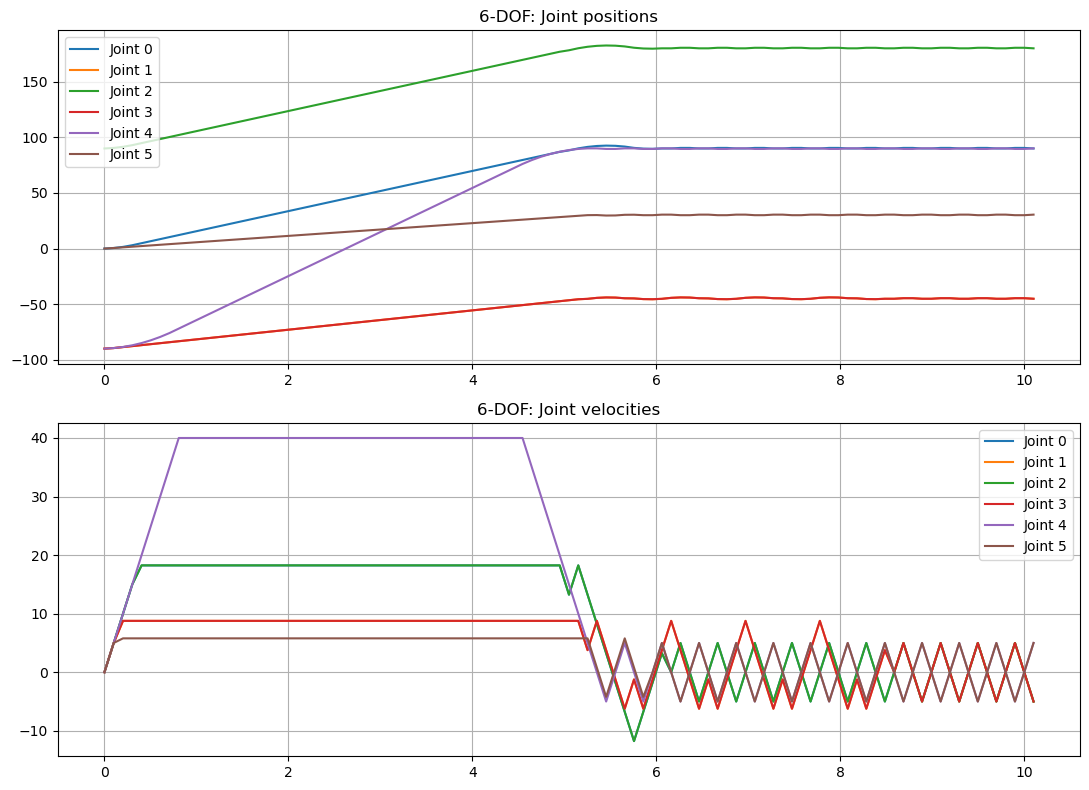

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd(), '..', '..')))
import numpy as np
import matplotlib.pyplot as plt
from models.model import MotionModel

model = MotionModel()

q0 = [0.0, -1.57, 1.57, -1.57, -1.57, 0.0]  # PT initial_q
q_target = [np.pi/2, -np.pi/4, np.pi, -np.pi/4, np.pi/2, np.pi/6]
# Scaling factors
alpha_v = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
alpha_a = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

acceleration = 50
max_vel = 40

# Simulation parameters
dt=0.1
t_end=10.0


t, qlog, qdlog, qddlog = model.simulate_joint_motion(q0, q_target, max_vel, acceleration, dt, t_end, alpha_v, alpha_a)
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(11,8))
for j in range(6):
    ax1.plot(t, np.rad2deg(qlog[:,j]), label=f'Joint {j}')
    ax2.plot(t, np.rad2deg(qdlog[:,j]), label=f'Joint {j}')
ax1.set_title('6-DOF: Joint positions'); ax1.legend(); ax1.grid(True)
ax2.set_title('6-DOF: Joint velocities'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()